##   Exploratory Data Analysis

Exploratory Data Analysis (EDA) is the process of examining and visualizing a dataset to understand its structure, patterns, and relationships before applying modeling or statistical techniques. In EDA projects, analysts use summary statistics, charts, and plots to uncover trends, detect anomalies, test assumptions, and gain insights that guide further data preprocessing, feature selection, or hypothesis generation.

Steps for an Exploratory Data Analysis (EDA) Project

1. Data Collection

* Gather data from sources such as CSV files,Excel files or databases.

* Ensure data is relevant, up to date, and in a usable format.

2. Data Cleaning

* Handle missing values (e.g., drop, impute).

* Remove or correct duplicate records.

* Fix inconsistent formatting (e.g., date formats, text casing).

* Handle incorrect data entries or outliers.

* Standardize categorical values (e.g., “Yes”, “yes”, “Y”).
3. Data Understanding

* Review column types and data structure.

* Use summary statistics to understand distributions.

* Identify categorical vs. numerical features.

* Perform sanity checks (e.g., no negative prices, date logic).

4. Univariate Analysis

* Analyze one feature at a time:

   1.Categorical: frequency counts, bar charts.

   2.Numerical: mean, median, histograms, boxplots.
   5. Bivariate Analysis

* Explore relationships between two variables:

   1.Categorical vs. categorical (cross-tabulation).

   2.Numerical vs. categorical (grouped statistics, boxplots).

   3.Numerical vs. numerical (scatter plots, correlation).

6. Multivariate Analysis

* Analyze interactions between three or more variables.
Use groupings, pivot tables, or visualizations like pairplots and heatmaps.

7. Feature Engineering

* Create new variables from existing data (e.g., total profit, sales per unit).

* Convert date/time into useful parts (month, weekday).

* Encode categorical variables if needed (for modeling).

8. Outlier Detection

* Identify and assess outliers using statistical or visual methods.

* Decide whether to keep, transform, or remove them based on context.

9. Trend and Pattern Analysis

* Use time series plots to detect seasonal or time-based patterns.
* Segment analysis by region, product category, customer type, etc.

10. Documentation & Reporting

Summarize findings with visualizations and insights.

Clearly communicate actionable recommendations.

Highlight data quality issues and limitations.



Geopolitical Event Noted

Introduction

This dataset provides daily records of global geopolitical tension and how financial markets react to it. It includes gold and silver prices—assets that typically rise during uncertainty—alongside the Geopolitical Risk Daily (GPRD) indexes, which measure overall risk, active conflicts, and threat levels. Together, these variables highlight how world events, political instability, and crisis periods influence market behavior. Although the EVENT column has limited entries, the trends in prices and GPRD scores still reveal clear signals of when global tensions increased or eased. This dataset is useful for understanding the relationship between geopolitical events and financial market movements.

In [289]:
# remove the warning massage
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

Import dataset

In [290]:
df = pd.read_csv(r"C:\datascience\dataset\Gold-Silver-GeopoliticalRisk_HistoricalData.csv")
df.head(3)

,DATE,GOLD_PRICE,GOLD_OPEN,GOLD_HIGH,GOLD_LOW,GOLD_CHANGE_%,SILVER_PRICE,SILVER_OPEN,SILVER_HIGH,SILVER_LOW,SILVER_CHANGE_%,GPRD,GPRD_ACT,GPRD_THREAT,EVENT
0,2025-09-10,3630.90,3633.61,3634.42,3620.90,-0.07,40.92,40.89,40.94,40.72,0.09,NaN,NaN,NaN,NaN
1,2025-09-09,3633.61,3637.10,3674.75,3625.33,-0.06,40.89,41.34,41.50,40.77,-1.13,NaN,NaN,NaN,NaN
2,2025-09-08,3635.84,3586.82,3646.60,3579.67,1.24,41.36,41.01,41.68,40.51,1.20,117.26,97.42,146.26,NaN


display the first 5 rows of the dataset

In [291]:
print(df.tail())

             DATE  GOLD_PRICE  GOLD_OPEN  GOLD_HIGH  GOLD_LOW  GOLD_CHANGE_%  \
10566  1985-01-08       302.0      302.0      302.0     302.0           1.27   
10567  1985-01-07       298.2      298.2      298.2     298.2          -1.62   
10568  1985-01-04       303.1      303.1      303.1     303.1           0.26   
10569  1985-01-03       302.3      302.3      302.3     302.3          -1.05   
10570  1985-01-02       305.5      305.5      305.5     305.5          -0.91   

       SILVER_PRICE  SILVER_OPEN  SILVER_HIGH  SILVER_LOW  SILVER_CHANGE_%  \
10566          6.01         6.01         6.01        6.01             3.62   
10567          5.80         5.80         5.80        5.80            -3.81   
10568          6.03         6.03         6.03        6.03            -0.99   
10569          6.09         6.09         6.09        6.09            -0.98   
10570          6.15         6.15         6.15        6.15            -3.30   

         GPRD  GPRD_ACT  GPRD_THREAT EVENT  
10566

Data cleaning

In [292]:
print(df.isna().sum())

DATE                   0
GOLD_PRICE             0
GOLD_OPEN              0
GOLD_HIGH              0
GOLD_LOW               0
GOLD_CHANGE_%          0
SILVER_PRICE           7
SILVER_OPEN            7
SILVER_HIGH            7
SILVER_LOW             7
SILVER_CHANGE_%        7
GPRD                   2
GPRD_ACT               2
GPRD_THREAT            2
EVENT              10560
dtype: int64


In [293]:
silver_columns = ['SILVER_PRICE', 'SILVER_HIGH', 'SILVER_LOW', 'SILVER_CHANGE_%','SILVER_OPEN','GPRD','GPRD_ACT','GPRD_THREAT']

for col in silver_columns:
    mean_value = df[col].mean()
    df[col].fillna(mean_value, inplace=True)

In [294]:
df['EVENT'].fillna('Unknown', inplace=True)
print(df.isna().sum())

DATE               0
GOLD_PRICE         0
GOLD_OPEN          0
GOLD_HIGH          0
GOLD_LOW           0
GOLD_CHANGE_%      0
SILVER_PRICE       0
SILVER_OPEN        0
SILVER_HIGH        0
SILVER_LOW         0
SILVER_CHANGE_%    0
GPRD               0
GPRD_ACT           0
GPRD_THREAT        0
EVENT              0
dtype: int64


In [295]:
# Remove spaces from column names
df.columns = df.columns.str.replace(' ','_')

In [296]:
 #Check for duplicate rows
df.duplicated().sum()

0

### Outlier Detection

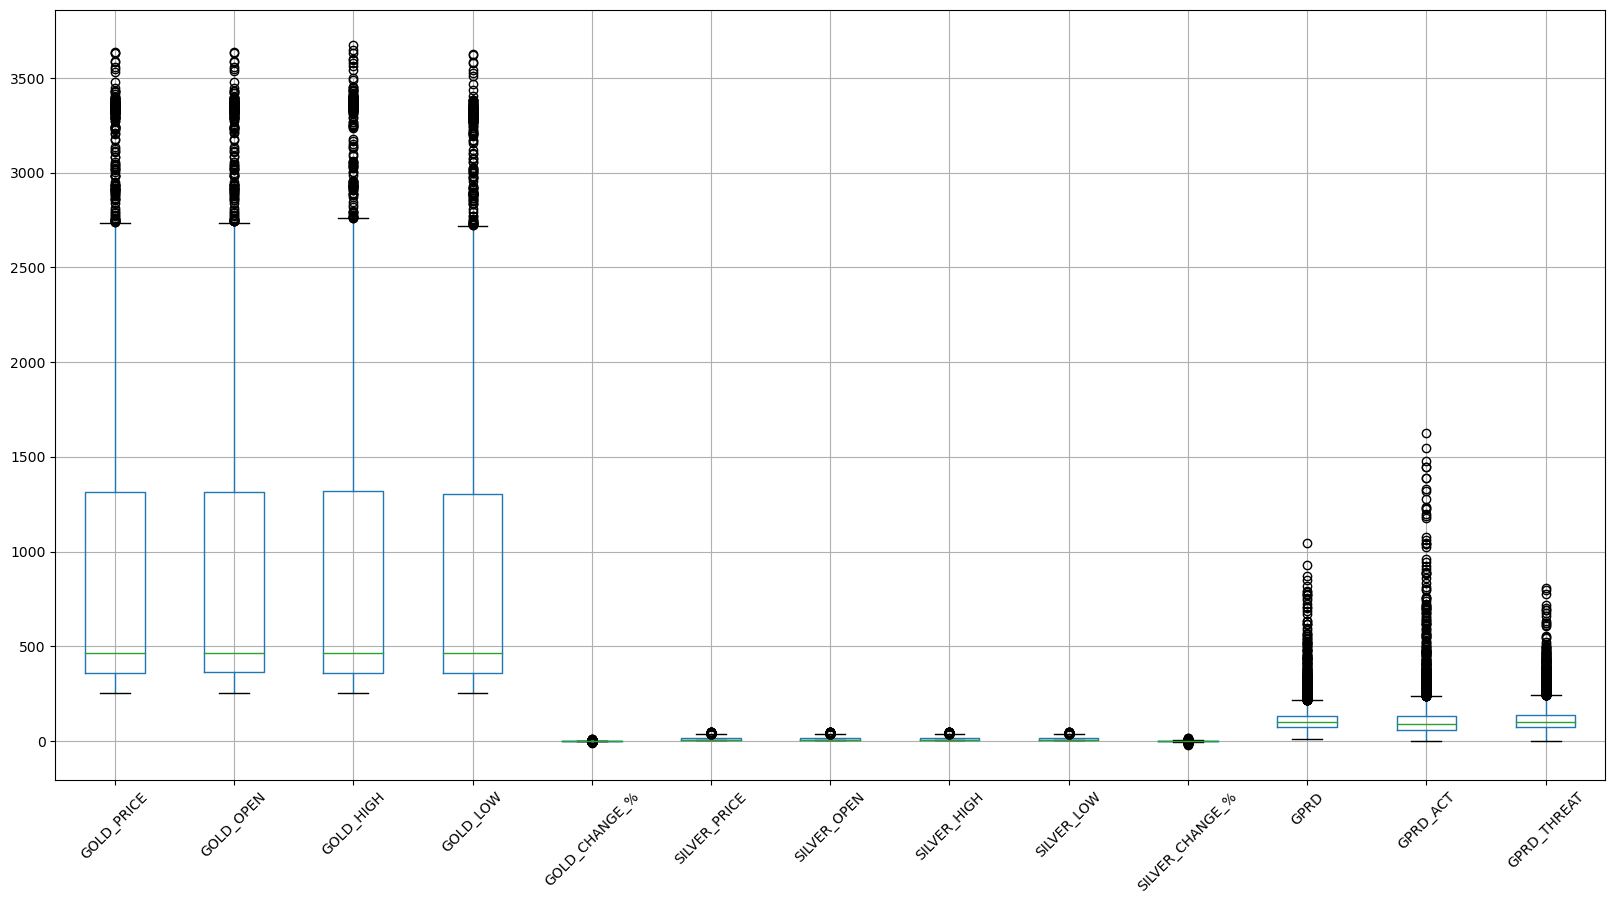

In [299]:
# plot boxplot for checking outliers
df.boxplot(figsize=(20,10))
plt.xticks(rotation=45)
plt.show()

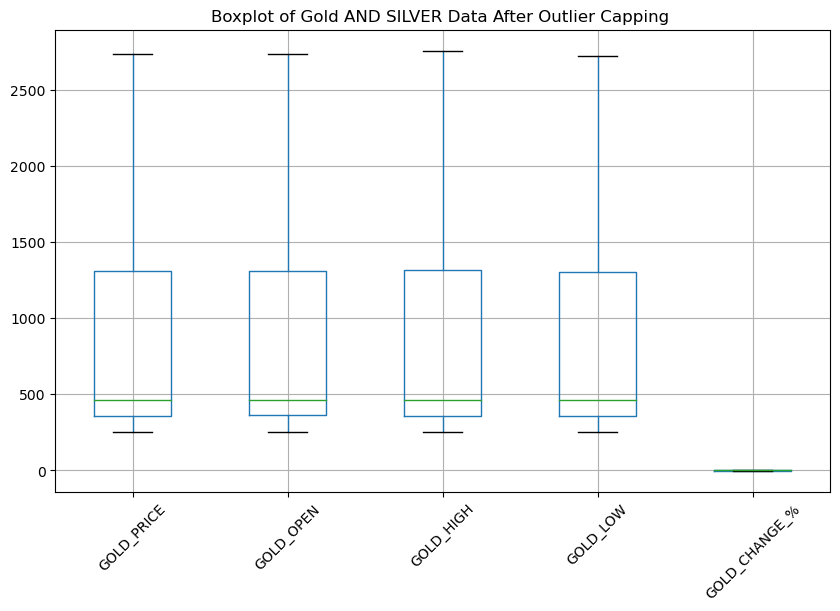

In [ ]:
gold_cols = ['GOLD_PRICE', 'GOLD_OPEN', 'GOLD_HIGH', 'GOLD_LOW', 'GOLD_CHANGE_%']
def cap_outliers_iqr(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR
        df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)
    return df
df = cap_outliers_iqr(df, gold_cols)
plt.figure(figsize=(10,6))
df[gold_cols].boxplot()
plt.title('Boxplot of Gold AND SILVER Data After Outlier Capping ')
plt.xticks(rotation=45)
plt.show()


In [ ]:
# Basic information about the dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10571 entries, 0 to 10570
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   DATE             10571 non-null  object 
 1   GOLD_PRICE       10571 non-null  float64
 2   GOLD_OPEN        10571 non-null  float64
 3   GOLD_HIGH        10571 non-null  float64
 4   GOLD_LOW         10571 non-null  float64
 5   GOLD_CHANGE_%    10571 non-null  float64
 6   SILVER_PRICE     10571 non-null  float64
 7   SILVER_OPEN      10571 non-null  float64
 8   SILVER_HIGH      10571 non-null  float64
 9   SILVER_LOW       10571 non-null  float64
 10  SILVER_CHANGE_%  10571 non-null  float64
 11  GPRD             10571 non-null  float64
 12  GPRD_ACT         10571 non-null  float64
 13  GPRD_THREAT      10571 non-null  float64
 14  EVENT            10571 non-null  object 
dtypes: float64(13), object(2)
memory usage: 1.2+ MB
None


In [ ]:
# Transform  DATE  column to datetime
df['DATE'] = pd.to_datetime(df['DATE'])

In [ ]:
# Use summary  to understand distributions.
print(df.describe())


         GOLD_PRICE     GOLD_OPEN     GOLD_HIGH      GOLD_LOW  GOLD_CHANGE_%  \
count  10571.000000  10571.000000  10571.000000  10571.000000   10571.000000   
mean     879.850379    880.052727    884.915867    874.689061       0.033626   
std      641.874464    641.445785    647.387692    636.366107       0.821272   
min      252.550000    252.350000    252.550000    252.550000      -1.825000   
25%      361.075000    362.150000    361.075000    361.075000      -0.430000   
50%      462.350000    464.620000    462.350000    462.350000       0.010000   
75%     1312.045000   1312.345000   1320.130000   1305.395000       0.500000   
max     2738.500000   2737.637500   2758.712500   2721.875000       1.895000   

       SILVER_PRICE   SILVER_OPEN   SILVER_HIGH   SILVER_LOW  SILVER_CHANGE_%  \
count  10571.000000  10571.000000  10571.000000  10571.00000     10571.000000   
mean      12.825364     12.810967     12.967795     12.66481         0.033753   
std        9.186919      9.181488   

1 What are the unique gprd, and how many records exist for each event?
2 What is the average GOLD_PRICE for each EVENT type?
3 Which EVENT corresponds to the highest average SILVER_PRICE?
4 Which DATE has the highest GPRD_ACT value?
5 Which DATE has the lowest GOLD_LOW value?
6 For each DATE what is the difference between average GOLD_PRICE and SILVER_PRICE?
7 What does the shape of the histogram indicate about the distribution of silver prices?
9 Bar plot of average GOLD_CHANGE_% per EVENT?
12 heat map?
13 Average Silver Price by Event Type?





In [ ]:
#1 What are the unique gprd, and how many records exist for each event?
print(df['GPRD'].value_counts())

97.43     24
72.01     22
106.86    19
89.53     18
122.69    16
          ..
135.35     1
157.28     1
100.24     1
150.21     1
115.68     1
Name: GPRD, Length: 6624, dtype: int64


In [ ]:
#2 What is the average GOLD_PRICE for each EVENT type
print(df.groupby('EVENT')['GOLD_PRICE'].mean())

EVENT
 Beginning of the Iraq War                                                 326.180000
 Bush Seeks UN Approval for Iraq War; Putin Threatens War with Georgia     316.850000
 Gulf War - Operation Desert Storm                                         399.000000
 London Bombings 7/7                                                       423.050000
 Paris Terrorist Attacks                                                  1070.370000
 Terrorist Threats in New York and Washington                              393.880000
 U.S. / Iran Tensions Escalate                                            1573.990000
 U.S. Bombing of Libya                                                     339.000000
 U.S. Invades Afghanistan                                                  289.700000
 War Fears U.S./Iraq; Terrorism in UK; Tension with North Korea            351.000000
Russia / Ukraine Tensions                                                 1887.560000
Unknown                                         

In [ ]:
#3 Which EVENT corresponds to the highest average SILVER_PRICE?
print(df.groupby('EVENT')['SILVER_PRICE'].mean())

EVENT
 Beginning of the Iraq War                                                 4.350000
 Bush Seeks UN Approval for Iraq War; Putin Threatens War with Georgia     4.550000
 Gulf War - Operation Desert Storm                                         4.200000
 London Bombings 7/7                                                       7.000000
 Paris Terrorist Attacks                                                  14.200000
 Terrorist Threats in New York and Washington                              6.660000
 U.S. / Iran Tensions Escalate                                            18.390000
 U.S. Bombing of Libya                                                     5.410000
 U.S. Invades Afghanistan                                                  4.600000
 War Fears U.S./Iraq; Terrorism in UK; Tension with North Korea            4.530000
Russia / Ukraine Tensions                                                 24.190000
Unknown                                                               

In [ ]:
#4 Which DATE has the highest GPRD_ACT value?
print(df.loc[df['GPRD_ACT'].idxmax(),'DATE'])


2001-09-25 00:00:00


In [ ]:
#5 Which DATE has the lowest GOLD_LOW value?
print(df.loc[df['GOLD_LOW'].idxmin(),'DATE'])

1999-08-25 00:00:00


In [ ]:
#6 For each DATE what is the difference between average GOLD_PRICE and SILVER_PRICE?
print(df.groupby('DATE')[['GOLD_PRICE', 'SILVER_PRICE']].mean().diff(axis=1))

            GOLD_PRICE  SILVER_PRICE
DATE                                
1985-01-02         NaN       -299.35
1985-01-03         NaN       -296.21
1985-01-04         NaN       -297.07
1985-01-07         NaN       -292.40
1985-01-08         NaN       -295.99
...                ...           ...
2025-09-05         NaN      -2697.49
2025-09-07         NaN      -2697.64
2025-09-08         NaN      -2697.14
2025-09-09         NaN      -2697.61
2025-09-10         NaN      -2697.58

[10571 rows x 2 columns]


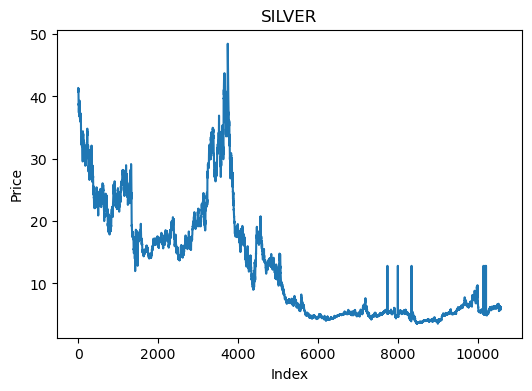

In [ ]:
#7 What does the shape of the histogram indicate about the distribution of silver prices?
plt.figure(figsize=(6,4))
plt.plot(df['SILVER_PRICE'])
plt.title('SILVER')
plt.xlabel('Index')
plt.ylabel('Price')
plt.show()

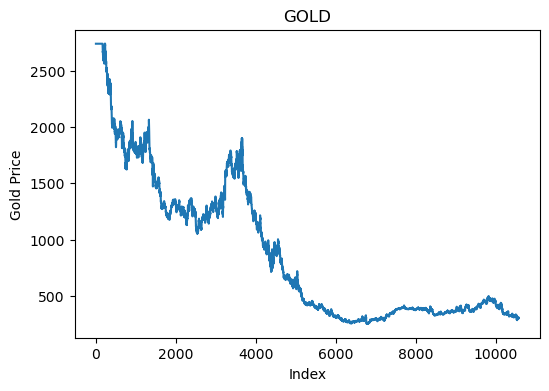

In [ ]:
#8
plt.figure(figsize=(6,4))
plt.plot(df['GOLD_PRICE'])
plt.title('GOLD')
plt.xlabel('Index')
plt.ylabel('Gold Price')
plt.show()


#9 line plot of average GOLD_CHANGE_% per EVENT
plt.figure(figsize=(8,6))
plt.xticks(rotation=45)
sns.lineplot(x='EVENT', y='GOLD_CHANGE_%', data=df, marker='o')
plt.title('Average Gold % Change by Event')
plt.show()
#11 line plot of average GOLD_CHANGE_% per EVENT
plt.figure(figsize=(8,6))
plt.xticks(rotation=45)
sns.lineplot(x='EVENT', y='SILVER_CHANGE_%', data=df, marker='o')
plt.title('Average silver % Change by Event')
plt.show()



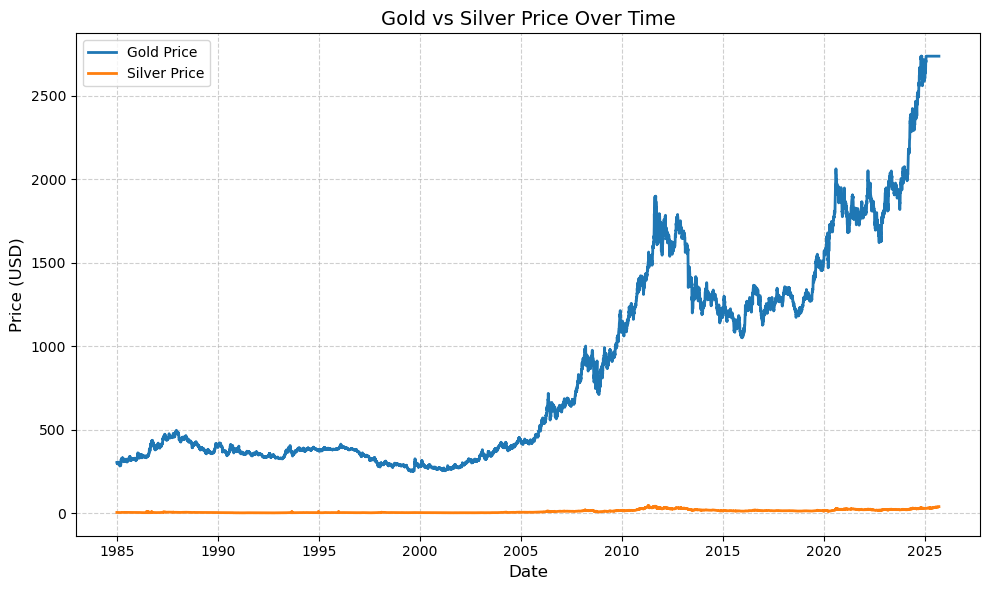

In [ ]:
# 11 During which periods did Gold prices rise faster than Silver prices?
plt.figure(figsize=(10,6))
plt.plot(df['DATE'], df['GOLD_PRICE'], label='Gold Price', linewidth=2)
plt.plot(df['DATE'], df['SILVER_PRICE'], label='Silver Price', linewidth=2)

# Add titles and labels
plt.title('Gold vs Silver Price Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

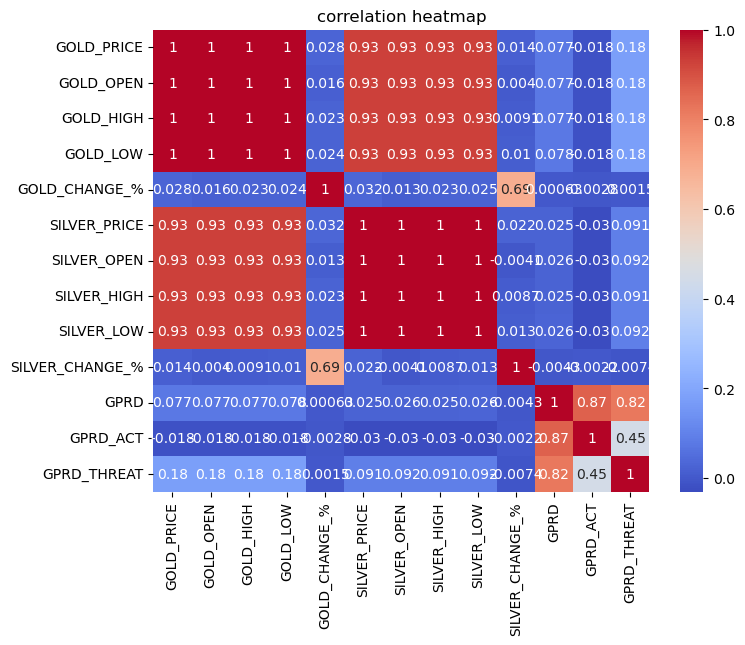

In [ ]:
#12 heat map
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title('correlation heatmap')
plt.show()

In [ ]:
#13 Average Silver Price by Event Type
sns.barplot(x='EVENT', y='SILVER_PRICE', data=df, estimator='mean', palette='coolwarm')
plt.xticks(rotation=45)
plt.title('Average Silver Price by Geopolitical Event')

Text(0.5, 1.0, 'Average Silver Price by Geopolitical Event')

### Feature Engineering

In [ ]:
# 1. Extract date/time features 
df['Year'] = df['DATE'].dt.year
df['Month'] = df['DATE'].dt.month
df['Day'] = df['DATE'].dt.day
# 2. Create new features
df['DayOfWeek'] = df['DATE'].dt.day_name()
df['Gold_Range'] = df['GOLD_HIGH'] - df['GOLD_LOW']
df['Silver_Range'] = df['SILVER_HIGH'] - df['SILVER_LOW']
df['Gold_Silver_Ratio'] = df['GOLD_PRICE'] / df['SILVER_PRICE']
df['Gold_Change_vs_Range'] = df['GOLD_CHANGE_%'] / (df['Gold_Range'] + 1e-5)  # avoid division by zero
df['Silver_Change_vs_Range'] = df['SILVER_CHANGE_%'] / (df['Silver_Range'] + 1e-5)
df['EVENT_Code'] = df['EVENT'].astype('category').cat.codes
print(df.head())

        DATE  GOLD_PRICE  GOLD_OPEN  GOLD_HIGH  GOLD_LOW  GOLD_CHANGE_%  \
0 2025-09-10      2738.5  2737.6375  2758.7125  2721.875          -0.07   
1 2025-09-09      2738.5  2737.6375  2758.7125  2721.875          -0.06   
2 2025-09-08      2738.5  2737.6375  2758.7125  2721.875           1.24   
3 2025-09-07      2738.5  2737.6375  2758.7125  2721.875           0.12   
4 2025-09-05      2738.5  2737.6375  2758.7125  2721.875           1.15   

   SILVER_PRICE  SILVER_OPEN  SILVER_HIGH  SILVER_LOW  ...  Year  Month  Day  \
0         40.92        40.89        40.94       40.72  ...  2025      9   10   
1         40.89        41.34        41.50       40.77  ...  2025      9    9   
2         41.36        41.01        41.68       40.51  ...  2025      9    8   
3         40.86        41.00        41.01       40.76  ...  2025      9    7   
4         41.01        40.69        41.44       40.55  ...  2025      9    5   

   DayOfWeek Gold_Range  Silver_Range  Gold_Silver_Ratio  \
0  Wedne

### Suggestions & Recommendations

Geopolitical Event Insights & Recommendations
1. Rising Geopolitical Intensity

Observation:
Spike in Event_Intensity (e.g., protests, conflicts, diplomatic escalations) strongly correlates with disruptions in regional stability and economic activity. Higher-intensity events often precede trade slowdowns and risk-score spikes.

Recommendation:

Integrate real-time geopolitical risk feeds into forecasting models.

Implement early-warning dashboards for sudden surges in conflict indicators.

Align supply chain and investment decisions with dynamic risk thresholds based on event intensity.
3. Economic & Diplomatic Drivers

Observation:
Geopolitical disruptions are often tied to economic sanctions, trade disputes, or diplomatic breakdowns. These factors significantly influence market volatility and resource accessibility.

Recommendation:

Track sanction announcements and policy shifts to anticipate market impacts.

Use macroeconomic indicators (inflation, commodity prices, trade balances) to forecast geopolitical tension spikes.

Develop scenario-based contingency plans for sudden diplomatic escalations.

4. Social Unrest & Public Sentiment

Observation:
Increased Social_Unrest_Index (e.g., strikes, protests, civil movements) aligns with rising internal political pressure and is often a precursor to larger geopolitical events.

Recommendation:

Monitor social sentiment analytics from news, social media, and NGO reports.

Implement risk scoring models for population-level unrest indicators.

Adjust operational exposure in regions with persistent or escalating public unrest.